# Codificação de Sinais Multimedia

## Trabalho Laboratorial 2

- 52146 - Margarida Andrade
- 52345 - Jorge Gonçalves
- 52708 - Helena Nina

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Exercício A

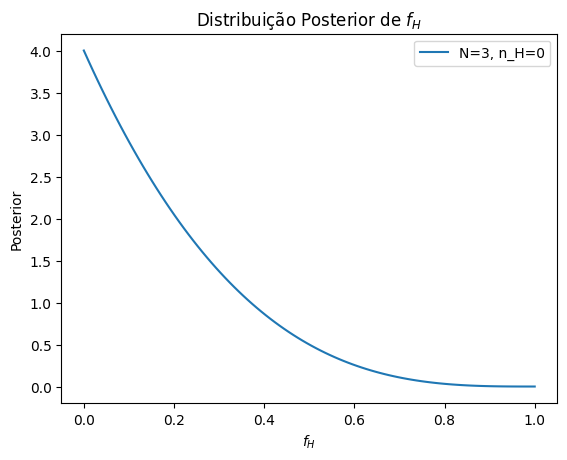

Probabilidade do próximo lançamento ser cara: 0.200


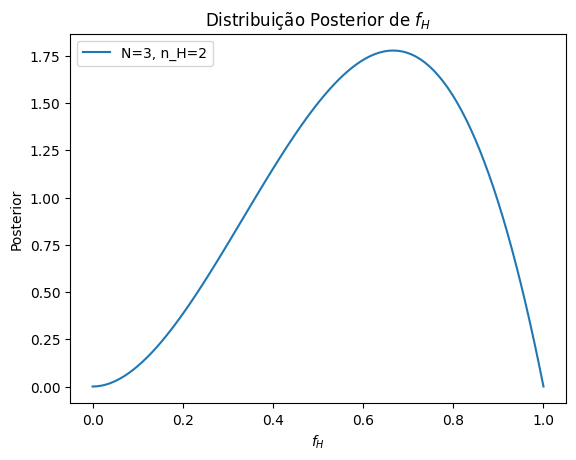

Probabilidade do próximo lançamento ser cara: 0.600


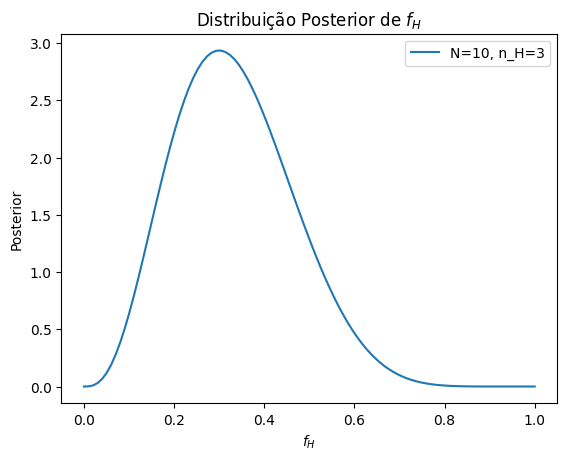

Probabilidade do próximo lançamento ser cara: 0.333


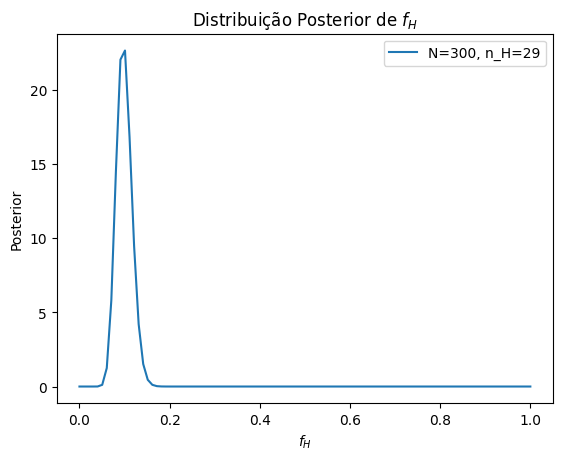

Probabilidade do próximo lançamento ser cara: 0.099


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plot_posterior(N, n_H):
    a = n_H + 1
    b = N - n_H + 1
    f_H = np.linspace(0, 1, 100)
    posterior = beta.pdf(f_H, a, b)
    plt.plot(f_H, posterior, label=f'N={N}, n_H={n_H}')
    plt.xlabel('$f_H$')
    plt.ylabel('Posterior')
    plt.title('Distribuição Posterior de $f_H$')
    plt.legend()
    plt.show()
    print(f'Probabilidade do próximo lançamento ser cara: {a/(a+b):.3f}')

# Exemplos do exercício
plot_posterior(3, 0)
plot_posterior(3, 2)
plot_posterior(10, 3)
plot_posterior(300, 29)

## Exercício B
### Alínea a.

In [4]:
# Prior dos algoritmos: [A, B, C]
P_algoritmo = np.array([0.40, 0.35, 0.25])

# Linhas: NC = 0,1,2,3,4 | Colunas: A,B,C
P_NC_dado_algoritmo = np.array([
    [0.05, 0.10, 0.20],
    [0.15, 0.20, 0.25],
    [0.40, 0.40, 0.30],
    [0.30, 0.20, 0.15],
    [0.10, 0.10, 0.10],
])

P_conjunta = np.zeros((5, 3)) # P_conjunta com as dimensões de P_NC_dado_algoritmo
for i in range(5):
    for j in range(3):
        # Calculo da distribuição conjunta (P_conjunta) multiplicando as probabilidades à priori pela verosimilhança.
        P_conjunta[i][j] = P_NC_dado_algoritmo[i][j] * P_algoritmo[j]
        
print(P_conjunta)

P_marginal = np.zeros(5) 
for i in range(5):
    for j in range(3):
        # Calculo da distribuição marginal dos níveis de compressão (P_marginal) somando as probabilidades conjuntas para cada NC.
        P_marginal[i] += P_conjunta[i][j]
        
print(f"\nP_marginal = {P_marginal}")
print(f"Soma = {P_marginal.sum().round(2)}")

[[0.02   0.035  0.05  ]
 [0.06   0.07   0.0625]
 [0.16   0.14   0.075 ]
 [0.12   0.07   0.0375]
 [0.04   0.035  0.025 ]]

P_marginal = [0.105  0.1925 0.375  0.2275 0.1   ]
Soma = 1.0


### Alínea b.

In [ ]:

def classifica_algoritmo(NC):
    """
    Função responsável por calcular a distribuição de probabilidades à posteriori de cada algoritmo de compressão,
    dado um nível de compressão observado (NC)."""
    
    result = np.zeros(3)
    for i in range(3):
        result[i] = P_conjunta[NC][i] / P_marginal[NC]
    return result

print(f"Classifica_algoritmo(NC = 3) = {classifica_algoritmo(3).round(3)}")
print(f"Soma = {classifica_algoritmo(3).sum().round(2)}")

Classifica_algoritmo(NC = 3) = [0.527 0.308 0.165]
Soma = 1.0


### Alínea c.

In [11]:
#Função que identifica qual o valor de nível de compressão que maximiza a verosimilhança
#j - índice do algoritmo
def max_verosimil(j):
    max = 0 #Variável que vai armazenar o maior valor de verosimilhança
    indice = 0 #Variável que vai armazenar o índice que corresponde ao maior valor de verosimilhança
    for i in range(5):
        if P_NC_dado_algoritmo[i][j] > max: #Verificar se o valor atual é maior do que o máximo guardado
            max = P_NC_dado_algoritmo[i][j] 
            indice = i
    return indice

print(f'Nível de compressão mais verosímil de A = {max_verosimil(0)}')
print(f'Nível de compressão mais verosímil de B = {max_verosimil(1)}')
print(f'Nível de compressão mais verosímil de C = {max_verosimil(2)}')

#Função que identifica qual o algoritmo mais provável para cada nível de compressão, 
#ou seja, o algoritmo que maximiza a probabilidade posteriori para cada nível de compressão.
#j - índice do algoritmo
def max_posteriori(i):
    max = 0 #Variável que vai armazenar o maior valor da probabilidade posteriori
    indice = 0 #Variável que vai armazenar o índice que corresponde ao maior valor da probabilidade posteriori
    for j in range(3):
        if P_NC_dado_algoritmo[i][j] > max:  #Verificar se o valor atual é maior do que o máximo guardado
            max = P_NC_dado_algoritmo[i][j]
            indice = j
    #Retornar o caracter correspondente ao algoritmo mais provável
    if indice == 0:
        return "A"
    elif indice == 1:  
        return "B"
    elif indice == 2:
        return "C" 

print(f'Algoritmo mais provável para NC=0 = {max_posteriori(0)}')
print(f'Algoritmo mais provável para NC=1 = {max_posteriori(1)}')
print(f'Algoritmo mais provável para NC=2 = {max_posteriori(2)}')
print(f'Algoritmo mais provável para NC=3 = {max_posteriori(3)}')
print(f'Algoritmo mais provável para NC=4 = {max_posteriori(4)}')

Nível de compressão mais verosímil de A = 2
Nível de compressão mais verosímil de B = 2
Nível de compressão mais verosímil de C = 2
Algoritmo mais provável para NC=0 = C
Algoritmo mais provável para NC=1 = C
Algoritmo mais provável para NC=2 = A
Algoritmo mais provável para NC=3 = A
Algoritmo mais provável para NC=4 = A


### Alínea d.

In [ ]:
NC = np.array([0, 1, 2, 3, 4])
P_NC_algoritmo = np.array(P_NC_dado_algoritmo)

def valor_esperado():
    """
    Função que calcula o valor esperado do número de NC para cada algoritmo.

    Returns:
        v_esperado (np.ndarray): Contém o valor esperado de NC para cada algoritmo (A, B e C).
    """
    v_esperado = np.dot(NC, P_NC_algoritmo)
    return v_esperado

v_esperado = valor_esperado()
print(f"Valor esperado para o algoritmo A: {v_esperado[0]:.2f}")
print(f"Valor esperado para o algoritmo B: {v_esperado[1]:.2f}")
print(f"Valor esperado para o algoritmo C: {v_esperado[2]:.2f}")

def variancia():
    """
    Função que calcula a variância de NC para cada algoritmo.

    Returns:
        var (np.ndarray): Contém o valor da variância de NC para cada algoritmo (A, B e C).
    """
    # Variância dada por: Var[X] = E[X^2] - (E[X])^2.
    # Onde E[X^2] = sum_i x_i^2 f_X(x_i).
    # Ou seja, E[NC^2] = sum_{i=0}^4 NC_i^2 * P(NC_i | Algoritmo).
    
    v_esperado2 = np.dot(NC**2, P_NC_algoritmo)  # E[X^2]
    var = v_esperado2 - valor_esperado()**2
    return var

var = variancia()
print(f"Variância para o algoritmo A: {var[0]:.4f}")
print(f"Variância para o algoritmo B: {var[1]:.4f}")
print(f"Variância para o algoritmo C: {var[2]:.4f}")

Valor esperado para o algoritmo A: 2.25
Valor esperado para o algoritmo B: 2.00
Valor esperado para o algoritmo C: 1.70
Variância para o algoritmo A: 0.9875
Variância para o algoritmo B: 1.2000
Variância para o algoritmo C: 1.5100


### Alínea e.

In [ ]:

n_amostras = 50000
np.random.seed(42)
algoritmos = np.array([0, 1, 2])  # A, B e C

# O uso do assert garante que as probabilidades somam 1.
assert np.allclose(np.sum(P_algoritmo), 1.0)
assert np.allclose(np.sum(P_NC_algoritmo, axis=0), 1.0)

# Aleatoriedade segundo o prior.
# Gera n_amostras escolhas aleatórias do algoritmo (A, B ou C),
# de acordo com as probabilidades à priori (P_algoritmo).
algoritmo_aleat = np.random.choice(algoritmos, n_amostras, p=P_algoritmo)

# Aleatoriedade segundo a verosimilhança P(NC|Algoritmo).
# Para cada amostra (cada algoritmo escolhido), sorteia um valor de NC
# de acordo com a distribuição condicional P(NC|Algoritmo).
NC_aleat = np.zeros(n_amostras, dtype=int)
for i, alg in enumerate(algoritmo_aleat):
    NC_aleat[i] = np.random.choice(NC, p=P_NC_algoritmo[:, alg])

# Array booleano que indica quais das amostras têm NC = 2.
NC_empirica = (NC_aleat == 2)

# Conta quantas vezes cada algoritmo foi escolhido apenas quando NC = 2.
# minlength define a quantidade de algoritmos (3).
estimativa_emp = np.bincount(algoritmo_aleat[NC_empirica], minlength=3)
P_empirico = estimativa_emp / NC_empirica.sum()

print('Estimativa empírica P(algoritmo|NC=2):')
print(f'A: {P_empirico[0]:.4f}, B: {P_empirico[1]:.4f}, C: {P_empirico[2]:.4f}')
print(f'Soma P_empirico = {P_empirico.sum().round(2)}')

# Comparação com o valor teórico
P_teorico = classifica_algoritmo(2)
print('\nValor teórico P(algoritmo|NC=2):')
print(f'A: {P_teorico[0]:.4f}, B: {P_teorico[1]:.4f}, C: {P_teorico[2]:.4f}')
print(f'Soma P_teorico = {P_teorico.sum().round(2)}')

Estimativa empírica P(algoritmo|NC=2):
A: 0.4234, B: 0.3767, C: 0.1999
Soma P_empirico = 1.0

Valor teórico P(algoritmo|NC=2):
A: 0.4267, B: 0.3733, C: 0.2000
Soma P_teorico = 1.0


## Exercício C
### Alínea a.
#### N = 4 e N = 10

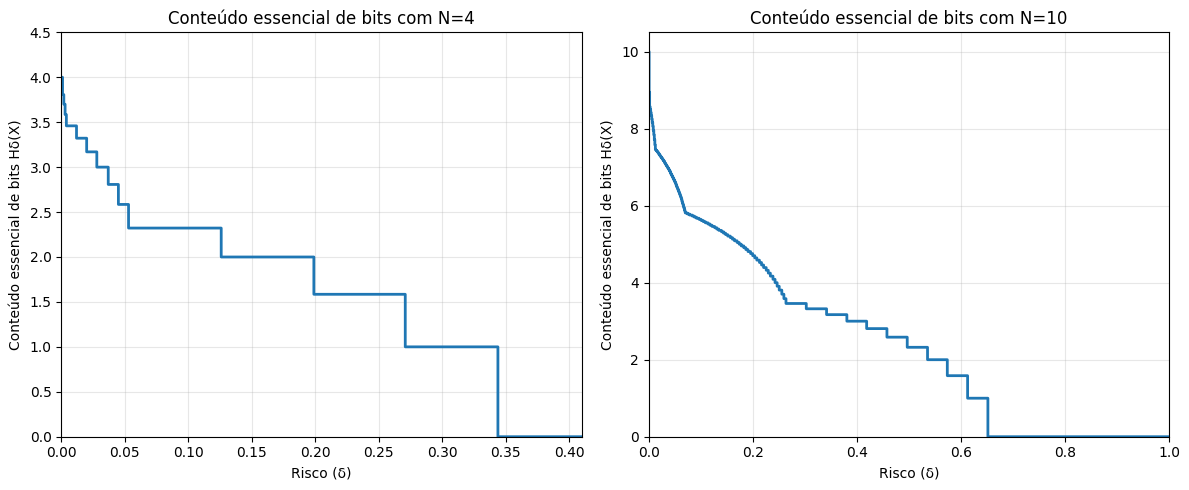

In [33]:
# Função para obter todas as combinações binárias possíveis com n bits.
def combinacoes_binarias(n):
    return [list(map(int, format(i, f'0{n}b'))) for i in range(2**n)]

# Função que calcula o conteúdo essencial de bits de um ensemble (Hδ(X)).
def conteudo_essencial(Ax, Px, gama):
    probabilidades = np.zeros(len(Ax))
    for seq in range(len(Ax)):
        prob = 1.0
        for bit in Ax[seq]:
            prob *= Px[bit]
        probabilidades[seq] = prob
    probabilidades = np.sort(probabilidades)[::-1]  # ordem decrescente

    conteudo = np.zeros(len(gama))
    for g, delta in enumerate(gama):
        soma = 0.0
        k = 0
        while soma < (1 - delta) and k < len(probabilidades):
            soma += probabilidades[k]
            k += 1
        conteudo[g] = np.log2(k) if k > 0 else 0.0
    return conteudo

Px = {0: 0.9, 1: 0.1}
gama = np.arange(0, 1, 0.001)

fig, graf = plt.subplots(1, 2, figsize=(12, 5))

# N = 4
n = 4
Ax_N4 = combinacoes_binarias(n)
conteudo_N4 = conteudo_essencial(Ax_N4, Px, gama)
graf[0].step(gama, conteudo_N4, where='post', linewidth=2)
graf[0].set_xlabel("Risco (δ)")
graf[0].set_ylabel("Conteúdo essencial de bits Hδ(X)")
graf[0].set_title("Conteúdo essencial de bits com N=4")
graf[0].set_xlim([0, 0.41])
graf[0].set_ylim([0, n + 0.5])
graf[0].grid(True, alpha=0.3)

# N = 10
n = 10
Ax_N10 = combinacoes_binarias(n)
conteudo_N10 = conteudo_essencial(Ax_N10, Px, gama)
graf[1].step(gama, conteudo_N10, where='post', linewidth=2)
graf[1].set_xlabel("Risco (δ)")
graf[1].set_ylabel("Conteúdo essencial de bits Hδ(X)")
graf[1].set_title("Conteúdo essencial de bits com N=10")
graf[1].set_xlim([0, 1])
graf[1].set_ylim([0, n + 0.5])
graf[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Alínea b.
#### N = 10, 210, 410, 610, 810, 1010


A calcular as curvas perfeitas...
  N = 10... OK
  N = 210... OK
  N = 410... OK
  N = 610... OK
  N = 810... OK
  N = 1010... OK


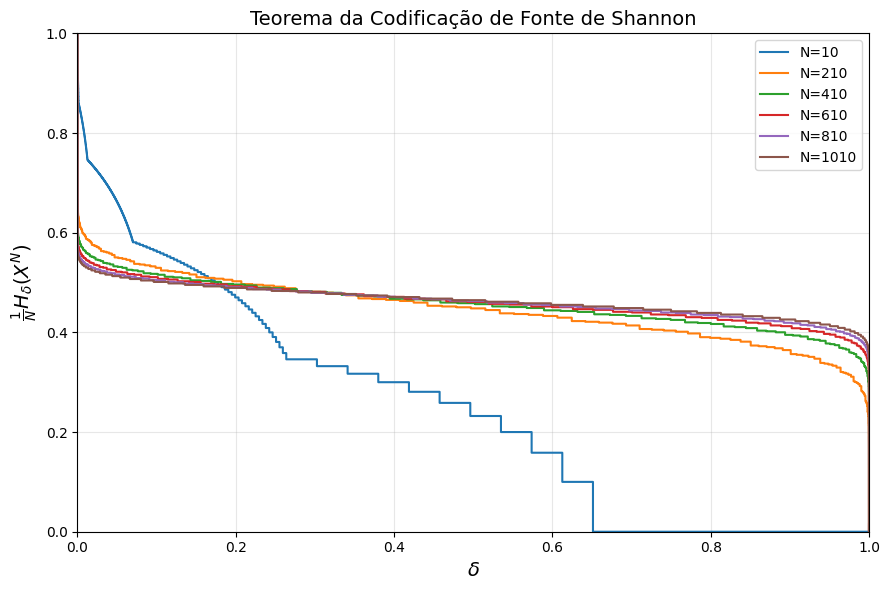

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

N_values = [10, 210, 410, 610, 810, 1010]
p0 = 0.9
p1 = 0.1

plt.figure(figsize=(9, 6))
print("A calcular as curvas perfeitas...")

for N in N_values:
    print(f"  N = {N}...", end=' ', flush=True)
    
    if N == 10:
        # --- CÁLCULO EXATO PARA N=10 ---
        # 2^10 = 1024 sequências. Adicionamos uma a uma.
        probs = []
        for r in range(N + 1):
            p_seq = (p0**(N-r)) * (p1**r)
            # Adiciona esta probabilidade exatamente o número de vezes que ela existe na realidade
            probs.extend([p_seq] * int(comb(N, r)))
        probs = np.array(probs)
        
        # Ordenar da mais provável para a menos provável
        probs_sorted = np.sort(probs)[::-1]
        
        cum_prob = np.cumsum(probs_sorted)
        delta_array = np.clip(1 - cum_prob, 0, 1)
        
        # O tamanho do conjunto cresce exatamente de 1 em 1
        cum_size = np.arange(1, len(probs) + 1)
        H_delta_norm = np.log2(cum_size) / N
        
    else:
        # AMOSTRAGEM PARA N >= 210
        amostras_por_r = max(1, int(np.ceil(1000 / (N + 1))))
        probs = []
        pesos = []
        
        for r in range(N + 1):
            p_seq = (p0**(N-r)) * (p1**r)
            peso = comb(N, r, exact=False) / amostras_por_r
            probs.extend([p_seq] * amostras_por_r)
            pesos.extend([peso] * amostras_por_r)
            
        probs = np.array(probs)
        pesos = np.array(pesos)
        
        # Ordenar e acumular multiplicando pelo peso (fração representativa)
        sort_idx = np.argsort(probs)[::-1]
        probs_sorted = probs[sort_idx]
        pesos_sorted = pesos[sort_idx]
        
        cum_prob = np.cumsum(probs_sorted * pesos_sorted)
        delta_array = np.clip(1 - cum_prob, 0, 1)
        
        # O tamanho cresce com os pesos fracionários (o que alisa as curvas para N grande)
        cum_size = np.cumsum(pesos_sorted)
        H_delta_norm = np.log2(cum_size) / N

    # Adicionar o ponto de ancoragem para o gráfico tocar no eixo (delta=1, H=0)
    delta_plot = np.concatenate(([1.0], delta_array))
    H_norm_plot = np.concatenate(([0.0], H_delta_norm))
    
    # Ordenar o eixo X para que o plt.step desenhe a linha corretamente
    sort_plot_idx = np.argsort(delta_plot)
    plt.step(delta_plot[sort_plot_idx], H_norm_plot[sort_plot_idx], where='post', label=f'N={N}')
    print("OK")

plt.xlabel(r'$\delta$', fontsize=14)
plt.ylabel(r'$\frac{1}{N} H_\delta(X^N)$', fontsize=14)
plt.title('Teorema da Codificação de Fonte de Shannon', fontsize=14)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()